# 12 - 手写 DPO / GRPO / OPD

配套笔记：[02 算法演化](../../../doc/05-RL/02-算法演化%20-%20DPO:GRPO:OPD.md)。先对照策略，再集中实现 loss，最后分别验收。

| 方法 | 数据来源 | 反馈来源 | loss 核心 | 模型角色 |
| --- | --- | --- | --- | --- |
| DPO | 固定偏好 pair | chosen / rejected 标签 | 偏好分差的二分类 loss | actor、ref |
| GRPO | actor rollout | RM 或规则 | 组内 advantage × clipped ratio + KL | actor、ref；可选 RM |
| ↳ DAPO | actor rollout | 原配方为规则奖励 | 非对称 clip、token 平均，无 ref KL | actor |
| OPD | student rollout | teacher | sampled-token logprob 差加权 | student、teacher |
| ↳ MOPD | student rollout | 按 domain 选 teacher | 沿用 OPD loss | student、多 teacher |

GRPO 本例用规则打分；DAPO 只验增量机制，MOPD 只验路由。模型角色不代表部署实例数。


## 0. 准备

依赖 torch、matplotlib。词表 32、hidden 32、1 层；无需下载模型或数据。按顺序运行全部 cell。

### 环境


In [1]:
import copy, torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
print('device:', DEVICE, '| torch', torch.__version__)


device: cpu | torch 2.8.0


### 共用组件

沿用 [01 notebook](11_basic_ppo.ipynb) 的 actor、response logprob 和 EOS mask。各方法只改数据来源、反馈与 loss。

> toy 约定：关闭 dropout；prompt 等长；定长生成后用 EOS mask 屏蔽无效位置；无 KV cache。训练与生成共用一个模型对象。

step 使用全局模型和 optimizer，各算法验收前分别初始化。


In [2]:
V, D, EOS = 32, 32, 0                            # 词表 / hidden / EOS token, toy 规模

class MiniLM(nn.Module):
    """共用 backbone: embedding + 1 层 causal transformer, 输出每位置 hidden"""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, D)
        layer = nn.TransformerEncoderLayer(D, nhead=4, dim_feedforward=4 * D,
                                           dropout=0.0, batch_first=True)  # 关 dropout: 前向确定
        self.blocks = nn.TransformerEncoder(layer, num_layers=1)
    def forward(self, ids):                      # [B,T] -> [B,T,D]
        causal = nn.Transformer.generate_square_subsequent_mask(ids.shape[1], device=ids.device)
        return self.blocks(self.emb(ids), mask=causal, is_causal=True)

class Actor(nn.Module):
    """LLM 本体: backbone + lm_head; DPO/GRPO 的 actor、OPD 的 student 与 teacher 都是它"""
    def __init__(self):
        super().__init__()
        self.lm, self.lm_head = MiniLM(), nn.Linear(D, V)
    def forward(self, ids):                      # -> [B,T,V] logits
        return self.lm_head(self.lm(ids))
    @torch.no_grad()
    def generate(self, ids, n_new):              # toy 版 rollout, 无 KV cache
        for _ in range(n_new):
            p = self(ids)[:, -1].softmax(-1)
            ids = torch.cat([ids, torch.multinomial(p, 1)], dim=1)
        return ids                               # 定长 n_new, EOS 之后靠 mask 屏蔽

def sft_logprob(model, ids, p_len):
    """SFT 式逐 token logprob, response 段 (B, T_resp); 01 篇 §4.3 原样"""
    logp = model(ids[:, :-1]).log_softmax(-1)              # (B, T-1, V) 位置 j 预测 ids[j+1]
    logp = logp.gather(-1, ids[:, 1:, None]).squeeze(-1)   # (B, T-1) 取实际 token 那一格
    return logp[:, p_len - 1:]                             # (B, T_resp) 只留 response 段

def seq_logprob(model, ids, p_len, mask):
    """整条 response 的 logprob (§2.4): 对 sft_logprob 的有效位求和, (B,)"""
    return (sft_logprob(model, ids, p_len) * mask).sum(-1)

def response_mask(ids, p_len):
    """01 篇 ppo_step 里那两行 EOS mask 抽成函数: 到首个 EOS(含) 为 1, 之后 pad 为 0"""
    eos = (ids[:, p_len:] == EOS).long()
    return (eos.cumsum(1) - eos == 0).float()      # (B, T_resp)

def check_frozen(name, frozen, trained, snap):
    """验收共用: 冻结的那个不能有梯度、不能被改动, 被训的那个梯度不能全 0"""
    assert all(p.grad is None for p in frozen.parameters()), f"{name}: 冻结模型有梯度!"
    assert all(torch.equal(p, q) for p, q in zip(frozen.parameters(), snap)), f"{name}: 冻结模型被改动!"
    # 只查 "不是 None" 的话, 全 0 梯度也算通过, 所以这里要求梯度非零
    assert any(p.grad is not None and p.grad.abs().max() > 0 for p in trained.parameters()), \
        f"{name}: 被训模型梯度全为 0!"


## 1. Loss：核心计算

本节只接收 logprob / reward 张量，不做 rollout 或参数更新。step 与验收放在 §2。

### 1.1 DPO ｜ 正文 §2.4

输入 actor / ref 对 chosen / rejected 的四份 **seq logprob**，形状均为 $(B,)$：

$$
d_i=\beta\left[(\log\pi_\theta(y_i^+)-\log\pi_{\rm ref}(y_i^+))
-(\log\pi_\theta(y_i^-)-\log\pi_{\rm ref}(y_i^-))\right],
\qquad
\mathcal L_{\rm DPO}=-\frac1B\sum_i\log\sigma(d_i)
$$

$d_i$ 是隐式 reward 的偏好分差。返回 loss 和观测用的平均 margin。


In [3]:
def dpo_loss(
    logp_chosen,
    logp_rejected,
    ref_logp_chosen,
    ref_logp_rejected,
    beta=0.1,
):
    """DPO loss (§2.4): RM 的 BT loss + 隐式 reward r̂ = β·log(π/ref); 输入均为 (B,)"""
    r_chosen = beta * (logp_chosen - ref_logp_chosen)
    r_rejected = beta * (logp_rejected - ref_logp_rejected)
    margin = r_chosen - r_rejected
    loss = -F.logsigmoid(margin).mean()             # -log σ(r̂_chosen - r̂_rejected)
    return loss, margin.mean()                      # margin 应随训练上涨


### 1.2 GRPO ｜ 正文 §3.4

$B$ 为 prompt 数，$G$ 为每题回答数，$T$ 为 response 长度。计算分三步：

| 函数 | 输入 | 输出 |
| --- | --- | --- |
| grpo_advantage | reward $(B,G)$ | 每条回答一个 $A_i$ |
| grpo_kl | actor / ref logprob $(B,G,T)$ | 每个 token 的 k3 |
| grpo_loss | new / old / ref logprob、$A$、mask | 标量 loss |

$$
A_i=\frac{R_i-\bar R}{\sigma_R+\varepsilon},
\qquad
\rho_{i,t}=\exp(\mathrm{new\_logp}_{i,t}-\mathrm{old\_logp}_{i,t}),
\qquad
D_{i,t}=e^{u_{i,t}}-u_{i,t}-1,\quad
u=\mathrm{ref\_logp}-\mathrm{new\_logp}
$$

$$
\mathcal L_{\rm GRPO}
=-\frac1B\sum_b\frac1G\sum_i\frac1{|y_{b,i}|}\sum_t
\left[\min\!\left(\rho_{b,i,t}A_{b,i},
\operatorname{clip}(\rho_{b,i,t},1-\epsilon,1+\epsilon)A_{b,i}\right)
-\beta D_{b,i,t}\right]
$$

求和只计有效 token。每条回答共用 $A_i$；先按回答内平均，再按回答平均。只有 new_logp 带梯度，old / ref logprob 和 $A$ 当常数。


In [4]:
def grpo_advantage(R, std_eps=1e-6):
    """组内标准化得 seq 级 advantage (§3.4); R / A 形状均为 (B, G)"""
    mean = R.mean(dim=1, keepdim=True)                    # (B, 1)  组均值, 即 baseline
    std = R.std(dim=1, keepdim=True, unbiased=False)      # (B, 1)  组内标准差
    return (R - mean) / (std + std_eps)                   # 每个 prompt 内独立归一

def grpo_kl(logp, ref_logp):
    """k3 KL 估计 (§3.4): 逐 token 非负的 KL 惩罚估计; 形状 (B, G, T_resp)"""
    u = ref_logp - logp        # u = -k1; ref 在前, 使 exp(u) = π_ref/π_θ 这个比值
    return u.exp() - u - 1     # k3 = k1 + (e^u - 1), 按当前 actor 分布采样时, 修正项均值为 0

def grpo_loss(new_logp, old_logp, ref_logp, A, mask, eps=0.2, beta=0.04):
    """GRPO actor loss (§3.4): seq 级 A_i × token 级 ratio, KL 单独一项"""
    ratio = (new_logp - old_logp).exp()             # ρ_{i,t}, logprob 差取 exp
    A = A.unsqueeze(-1)                             # (B,G) -> (B,G,1), 广播到整条
    surr1 = ratio * A                               # 不截断
    surr2 = ratio.clamp(1 - eps, 1 + eps) * A       # 截断到 [1-ε, 1+ε]
    surrogate = torch.min(surr1, surr2)             # 只截断 A>0 时的上界、A<0 时的下界
    kl = grpo_kl(new_logp, ref_logp)                # k3, 逐 token ≥ 0
    token_loss = -(surrogate - beta * kl)           # 取负: 最大化目标 -> 最小化 loss
    lengths = mask.sum(-1).clamp_min(1)             # (B, G)  每条有效长度 |y_i|
    per_seq = (token_loss * mask).sum(-1) / lengths # 先按 1/|y_i| 平均, pad 位不算
    return per_seq.mean()                           # 再按 1/G 平均, B 维一并平均


### 1.3 DAPO 增量 ｜ 正文 §3.6

> 沿用 §1.2 的组内 $A_i$ 和 token ratio。只改三处：删 KL、分开 clip 上下界、按全 batch 有效 token 平均。

$$
\mathcal L_{\rm DAPO}
=-\frac{\sum_{b,i,t}m_{b,i,t}\min\!\left(
\rho_{b,i,t}A_{b,i},
\operatorname{clip}(\rho_{b,i,t},1-\epsilon_{\rm low},1+\epsilon_{\rm high})A_{b,i}
\right)}{\sum_{b,i,t}m_{b,i,t}}
$$

无需 ref_logp。输入形状沿用 GRPO；筛组补采与 reward 处理见 §2.3。


In [5]:
def dapo_loss(new_logp, old_logp, A, mask, eps_low=0.2, eps_high=0.28):
    """DAPO loss: logp / mask 为 (B,G,T), A 为 (B,G); old_logp 与 A 当常数。"""
    ratio = (new_logp - old_logp).exp()
    A = A.unsqueeze(-1)
    surrogate = torch.minimum(
        ratio * A,
        ratio.clamp(1 - eps_low, 1 + eps_high) * A,
    )
    return -(surrogate * mask).sum() / mask.sum().clamp_min(1)


### 1.4 OPD / MOPD ｜ 正文 §4.5

这里只实现 **sampled-token** 分支。输入 student / teacher 对 student 已采 token 的 logprob，以及 mask，形状均为 $(B,T)$。

$$
\Delta_t=\log\pi_T(y_t\mid x,y_{<t})-\log\pi_S(y_t\mid x,y_{<t}),
\qquad
\mathcal L_{\rm sampled}
=-\frac{\sum_{i,t}m_{i,t}\operatorname{stopgrad}(\Delta_{i,t})\log\pi_S(y_{i,t}\mid x_i,y_{i,<t})}
{\sum_{i,t}m_{i,t}}
$$

gap 只作权重，梯度只走 student logprob。该代理 loss 的数值不等于 KL；验收比较梯度。

**MOPD 沿用同一个 loss**，只改变 teacher 的选择，见 §2.5。top-k / full-vocab 分支未实现。


In [6]:
def sampled_opd_loss(student_logp, teacher_logp, mask):
    """sampled-token OPD loss (§4.3): gap 只定升降, 梯度只走 student logprob"""
    delta = (teacher_logp - student_logp).detach()   # Δ_t > 0 推高该 token, < 0 压低
    token_loss = -delta * student_logp               # detach 后 Δ 是常数权重
    loss = (token_loss * mask).sum() / mask.sum().clamp_min(1)   # 有效位上 token 级平均
    return loss, delta


## 2. 验收：从 loss 到训练 step

按 **固定输入检查 → 接起 step → toy 训练趋势** 验收。DAPO 只查机制，MOPD 只查路由。

| 检查 | 验什么 |
| --- | --- |
| 数值 / 手算对照 | loss、advantage、clip、平均方式 |
| 采样对照 | k3 的均值；OPD 代理 loss 的梯度 |
| 梯度与参数检查 | 冻结模型不变、被训模型有梯度、mask 不泄漏 |
| toy 曲线 | 简化任务中，数据到更新的流程能否工作 |

曲线变好不能代替前面的检查，也不代表真实任务效果。

### 2.1 DPO

**① 验 loss**：对齐 BCE；另查 ref 公共项抵消、交换 pair 后 margin 反号。


In [7]:
# 对现成函数: -log sigma(d) 就是 label 恒为 1 的二分类 CE
torch.manual_seed(0)
lc, lr_, rc, rr = (torch.randn(6, device=DEVICE) for _ in range(4))
loss, mg = dpo_loss(lc, lr_, rc, rr, beta=0.1)
d = 0.1 * ((lc - rc) - (lr_ - rr))                                  # 手写分差 d
assert torch.allclose(loss, F.binary_cross_entropy_with_logits(d, torch.ones_like(d)))
assert torch.allclose(mg, d.mean())
print("对函数    dpo_loss == F.binary_cross_entropy_with_logits; margin == d 的均值  OK")

# 断言: ref 两条同加常数 -> d 不变 (§2.3 里 Z(x) 被相减消掉); 交换 pair -> d 反号
c = torch.randn(1, device=DEVICE)
assert torch.allclose(loss, dpo_loss(lc, lr_, rc + c, rr + c, beta=0.1)[0], atol=1e-6)
assert torch.allclose(dpo_loss(lr_, lc, rr, rc, beta=0.1)[1], -mg)
print("断言      ref 公共项相减即消; 交换 chosen/rejected 后 d 反号  OK")


对函数    dpo_loss == F.binary_cross_entropy_with_logits; margin == d 的均值  OK
断言      ref 公共项相减即消; 交换 chosen/rejected 后 d 反号  OK


**② 接起 step**

> 调用 §1.1 的 dpo_loss。actor / ref 各前向 chosen 与 rejected，得到四份 seq logprob；只有 actor 更新。

toy pair 固定：chosen 为四个 token 7，rejected 为四个 token 8，prompt 相同。无 rollout。


In [8]:
def dpo_step(
    ids_chosen,
    mask_chosen,
    ids_rejected,
    mask_rejected,
    p_len,
):
    """一个 DPO step (§2.4): 4 次 teacher-forcing 前向 + 1 次反向; 无生成、无采样"""
    logp_chosen   = seq_logprob(actor, ids_chosen,   p_len, mask_chosen)     # 带梯度
    logp_rejected = seq_logprob(actor, ids_rejected, p_len, mask_rejected)
    with torch.no_grad():                                                    # ref 冻结, 只前向
        ref_chosen   = seq_logprob(ref, ids_chosen,   p_len, mask_chosen)
        ref_rejected = seq_logprob(ref, ids_rejected, p_len, mask_rejected)
    loss, margin = dpo_loss(logp_chosen, logp_rejected, ref_chosen, ref_rejected)
    opt.zero_grad(); loss.backward(); opt.step()
    return loss.item(), margin.item()                                        # margin 应随训练上涨


In [9]:
# 梯度流向: 建一组新模型, 先跑一步
torch.manual_seed(0)
actor = Actor().to(DEVICE); ref = copy.deepcopy(actor).eval()
opt = torch.optim.Adam(actor.parameters(), lr=2e-3)
B, p_len, T_resp = 16, 3, 4
prompt = torch.tensor([[1, 2, 3]], device=DEVICE).repeat(B, 1)
chosen_ids   = torch.cat([prompt, torch.full((B, T_resp), 7, device=DEVICE)], 1)
rejected_ids = torch.cat([prompt, torch.full((B, T_resp), 8, device=DEVICE)], 1)
pair_mask = torch.ones(B, T_resp, device=DEVICE)

snap = [p.clone() for p in ref.parameters()]
l, m = dpo_step(chosen_ids, pair_mask, rejected_ids, pair_mask, p_len)
check_frozen('DPO', ref, actor, snap)
print(f"梯度流向  loss={l:+.4f} margin={m:+.4f} | ref 无梯度且不变, actor 梯度非零  OK")


梯度流向  loss=+0.6931 margin=-0.0000 | ref 无梯度且不变, actor 梯度非零  OK


**③ 训练 50 步**：要求 margin 明显增加；同时观察 chosen / rejected 各自的 seq logprob，区分增量来自哪一侧。


曲线      margin -0.000 -> +3.811
          拆开看 seq logprob: chosen +11.2 nats, rejected -27.2 nats -> 增量的 71% 来自压低 rejected


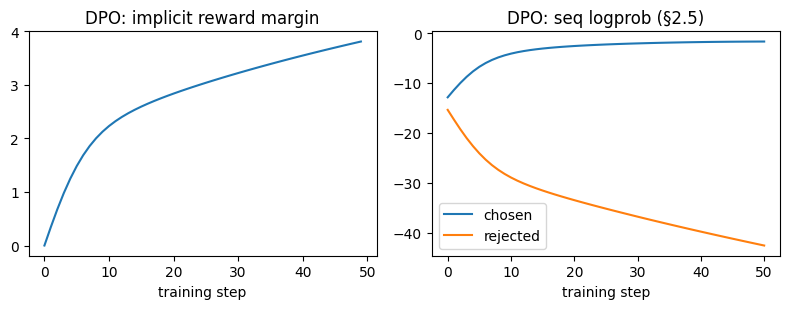

In [10]:
import matplotlib.pyplot as plt

# 曲线: 重建模型从头训 50 步
torch.manual_seed(0)
actor = Actor().to(DEVICE); ref = copy.deepcopy(actor).eval()
opt = torch.optim.Adam(actor.parameters(), lr=2e-3)

@torch.no_grad()
def watch():                                     # 只作观测, 不进 loss
    return (seq_logprob(actor, chosen_ids,   p_len, pair_mask).mean().item(),
            seq_logprob(actor, rejected_ids, p_len, pair_mask).mean().item())

c0, r0 = watch()
dpo_curve, lp_c, lp_r = [], [c0], [r0]
for _ in range(50):
    _, mm = dpo_step(chosen_ids, pair_mask, rejected_ids, pair_mask, p_len)
    dpo_curve.append(mm)
    cc, rrr = watch(); lp_c.append(cc); lp_r.append(rrr)

assert dpo_curve[-1] > dpo_curve[0] + 0.5, "DPO margin 没有明显上升!"
d_c, d_r = lp_c[-1] - lp_c[0], lp_r[-1] - lp_r[0]
print(f'曲线      margin {dpo_curve[0]:+.3f} -> {dpo_curve[-1]:+.3f}')
print(f'          拆开看 seq logprob: chosen {d_c:+.1f} nats, rejected {d_r:+.1f} nats '
      f'-> 增量的 {abs(d_r) / (abs(d_c) + abs(d_r)):.0%} 来自压低 rejected')

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].plot(dpo_curve); ax[0].set_title('DPO: implicit reward margin')
ax[1].plot(lp_c, label='chosen'); ax[1].plot(lp_r, label='rejected')
ax[1].set_title('DPO: seq logprob (§2.5)'); ax[1].legend()
for a in ax: a.set_xlabel('training step')
plt.tight_layout(); plt.show()


> DPO 约束偏好分差，不保证 chosen 的绝对概率一直上升。本例另记录两条 logprob 的变化，不能只凭 margin 上涨判断行为。


### 2.2 GRPO

**① 验 loss 与部件**

- **advantage**：手算对照、组内均值 / 标准差、平移与正缩放、同分组为零。
- **k3**：按 actor 分布采样 40 万次，均值对照全词表精确 KL；这里只验数值估计，不验 KL 梯度。
- **loss**：相同广播 advantage、等长、$\beta=0$ 时对照 01 的 PPO loss；另查变长平均与 clip 梯度方向。

> 等长条件用于对齐两份实现的平均方式，不表示 PPO 与 GRPO 本身等价。


In [11]:
# advantage: 手算答案 + 标准化性质
R = torch.tensor([[1., 2., 3., 4.], [0., 5., 5., 10.]], device=DEVICE)
A = grpo_advantage(R)
A_expected = torch.tensor([[-3., -1., 1., 3.], [-2., 0., 0., 2.]], device=DEVICE)
A_expected[0] /= 5 ** 0.5
A_expected[1] /= 2 ** 0.5
assert torch.allclose(A, A_expected, atol=1e-5)  # 手算基准; epsilon 造成微小偏差
assert torch.allclose(A.mean(1), torch.zeros(2, device=DEVICE), atol=1e-6)       # mean=0
assert torch.allclose(A.std(1, unbiased=False), torch.ones(2, device=DEVICE), atol=1e-4)  # std=1
assert torch.allclose(grpo_advantage(R + 100.), A, atol=1e-4)                    # 平移不变
assert torch.allclose(grpo_advantage(R * 3.), A, atol=1e-4)                      # 正缩放不变
A_flat = grpo_advantage(torch.full((1, 4), 7., device=DEVICE))                   # 全对全错组
assert torch.equal(A_flat, torch.zeros(1, 4, device=DEVICE))
z3 = torch.zeros(1, 4, 2, device=DEVICE); n0 = z3.clone().requires_grad_(True)
grpo_loss(n0, z3, z3, A_flat, torch.ones_like(z3), beta=0.0).backward()
assert torch.allclose(n0.grad, torch.zeros_like(n0.grad))                        # 整组无梯度
print("手算对照  grpo_advantage; 组内 mean≈0/std≈1; 平移与正缩放近似不变; 同分组 A=0, beta=0 时无梯度  OK")

# 对现成函数: k3 的采样均值应收敛到 F.kl_div 给的精确 KL
torch.manual_seed(0)
lt, lref = torch.randn(8, device=DEVICE), torch.randn(8, device=DEVICE)
logp_th, logp_ref = lt.log_softmax(-1), lref.log_softmax(-1)
kl_exact = F.kl_div(logp_ref, logp_th, reduction='sum', log_target=True)  # 现成函数给的精确 KL
idx = torch.multinomial(logp_th.exp(), 400_000, replacement=True)   # 按 π_θ 采样
k1 = logp_th[idx] - logp_ref[idx]
k3 = grpo_kl(logp_th[idx], logp_ref[idx])
assert (k1.mean() - kl_exact).abs() < 0.01 and (k3.mean() - kl_exact).abs() < 0.01   # 采样均值收敛到它
assert (k1 < 0).any() and (k3 >= 0).all()                                            # 单样本正负性检查, 不是 KL 梯度检查
assert torch.equal(grpo_kl(logp_th, logp_th), torch.zeros(8, device=DEVICE))
print(f"对函数    grpo_kl: F.kl_div={kl_exact:.4f} vs 采样 k1={k1.mean():.4f} / k3={k3.mean():.4f}; "
      f"k1 有负值、k3 恒非负  OK")

# 对现成函数: 等长且 beta=0 时, grpo_loss 应与 01 篇的 ppo_loss loss 相等
def ppo_loss_ref(new_logp, old_logp, adv, mask, eps=0.2):
    """01 篇 §4.3 的 ppo_loss 原样搬来当参照"""
    ratio = (new_logp - old_logp).exp()
    surr1, surr2 = ratio * adv, ratio.clamp(1 - eps, 1 + eps) * adv
    return (-torch.min(surr1, surr2) * mask).sum() / mask.sum()

torch.manual_seed(0)
B_, G_, T_ = 2, 3, 5
new, old = torch.randn(B_, G_, T_, device=DEVICE), torch.randn(B_, G_, T_, device=DEVICE)
Ag, m_all = torch.randn(B_, G_, device=DEVICE), torch.ones(B_, G_, T_, device=DEVICE)
flat = lambda t: t.reshape(-1, T_)
adv_bcast = Ag.reshape(-1, 1).expand(-1, T_)                        # A_i 广播成 PPO 的逐 token A_t
assert torch.allclose(grpo_loss(new, old, old, Ag, m_all, beta=0.0),                  # 等长时相同
                      ppo_loss_ref(flat(new), flat(old), adv_bcast, flat(m_all)), atol=1e-6)
m_var = m_all.clone(); m_var[0, 0, 3:] = 0                          # 让第一条变短
assert not torch.allclose(grpo_loss(new, old, old, Ag, m_var, beta=0.0),              # 不等长才分开
                          ppo_loss_ref(flat(new), flat(old), adv_bcast, flat(m_var)), atol=1e-3)
one3, A_pos = torch.ones(1, 1, 1, device=DEVICE), torch.tensor([[1.]], device=DEVICE)
zero3, A_neg = torch.zeros(1, 1, 1, device=DEVICE), torch.tensor([[-1.]], device=DEVICE)
assert torch.allclose(grpo_loss(zero3, zero3, zero3, A_pos, one3, beta=0.0), -A_pos.mean())  # ratio=1
n1 = one3.clone().requires_grad_(True)                              # ratio=e~2.72, 出上界
grpo_loss(n1, zero3, zero3, A_pos, one3, beta=0.0).backward()
assert torch.allclose(n1.grad, torch.zeros_like(n1.grad))                            # 顺优势 -> 梯度 0
n2 = one3.clone().requires_grad_(True)
grpo_loss(n2, zero3, zero3, A_neg, one3, beta=0.0).backward()
assert not torch.allclose(n2.grad, torch.zeros_like(n2.grad))                        # 逆优势 -> 保留
print("对函数    grpo_loss: 等长时 == 01 的 ppo_loss, 不等长才分开 (§3.6 两级平均); "
      "ratio=1 退化成 -A_i, clip 方向对  OK")


手算对照  grpo_advantage; 组内 mean≈0/std≈1; 平移与正缩放近似不变; 同分组 A=0, beta=0 时无梯度  OK
对函数    grpo_kl: F.kl_div=0.8208 vs 采样 k1=0.8224 / k3=0.8192; k1 有负值、k3 恒非负  OK
对函数    grpo_loss: 等长时 == 01 的 ppo_loss, 不等长才分开 (§3.6 两级平均); ratio=1 退化成 -A_i, clip 方向对  OK


**② 接起 step**

> 调用 §1.2 的 advantage、KL 和 loss。每题采 $G$ 条 → reward_fn 打分 → 组内标准化 → 取 old / ref logprob → 更新 actor。

reward_fn 可以封装 RM 或规则。本例只统计回答中 token 7 的出现次数；不加载 RM。ref 不变，actor 梯度须非零。


In [12]:
TARGET = 7                                       # toy verifier: 目标 token 出现越多分越高

def token_count_reward(ids, p_len, mask):
    """RLVR 的 toy 版 (§3.2): 一段规则, 没有参数、不用训练; 返回 (B*G,)"""
    return ((ids[:, p_len:] == TARGET).float() * mask).sum(1)

def grpo_step(prompt, reward_fn, G=4, n_new=6, update_epochs=2, beta=0.04):
    """一个 GRPO step (§3.4): 每 prompt 采 G 条 -> reward_fn 打分 -> 组内标准化 -> ratio + clip"""
    B, p_len = prompt.shape
    # 1) rollout: 同一 prompt 复制 G 份, 每份独立采样 (推理负载)
    flat = prompt[:, None].expand(B, G, p_len).reshape(B * G, p_len)
    with torch.no_grad():
        ids = actor.generate(flat, n_new)                                # (B*G, p_len+n_new)
        mask = response_mask(ids, p_len)                                 # (B*G, n_new)
        R = reward_fn(ids, p_len, mask).reshape(B, G)                    # 2) 打分; 本例使用规则
        A = grpo_advantage(R)                                            # 3) 组内统计顶替 critic+GAE
        old_logp = sft_logprob(actor, ids, p_len).reshape(B, G, n_new)   # ρ 的分母
        ref_logp = sft_logprob(ref, ids, p_len).reshape(B, G, n_new)     # k3 的基准
    mask = mask.reshape(B, G, n_new)
    # 4) update: 同一批 rollout 复用 update_epochs 次 (训练负载)
    for _ in range(update_epochs):
        new_logp = sft_logprob(actor, ids, p_len).reshape(B, G, n_new)   # 唯一带梯度的前向
        loss = grpo_loss(new_logp, old_logp, ref_logp, A, mask, beta=beta)
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item(), R.mean().item()                                  # R 均值应随训练上涨


In [13]:
# 梯度流向: 建一组新模型, 先跑一步
torch.manual_seed(0)
actor = Actor().to(DEVICE); ref = copy.deepcopy(actor).eval()
opt = torch.optim.Adam(actor.parameters(), lr=1e-3)
snap = [p.clone() for p in ref.parameters()]
l, r = grpo_step(torch.randint(1, V, (2, 3), device=DEVICE), token_count_reward)
check_frozen('GRPO', ref, actor, snap)
print(f"梯度流向  loss={l:+.4f} reward={r:.4f} | ref 无梯度且不变, actor 梯度非零  OK")


梯度流向  loss=-0.0408 reward=0.1250 | ref 无梯度且不变, actor 梯度非零  OK


**③ 训练 100 步**：生成长度为 6，reward 上限为 6；比较前后各 20 步的平均 reward。

> 曲线取 $\beta=0$，只验 reward 分支；上面的单步检查取默认 $\beta=0.04$。这不是 KL 约束效果的对比实验。


曲线      verifier reward 0.522 -> 5.964   (上限 6 = n_new)


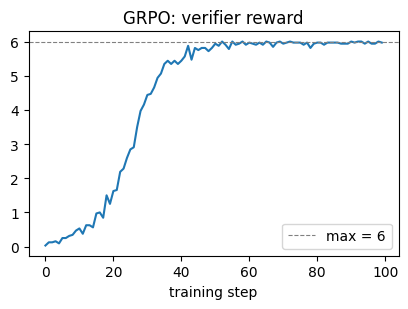

In [14]:
# 曲线: 重建模型从头训 100 步; beta=0 把 reward 信号单独看清
torch.manual_seed(1)
actor = Actor().to(DEVICE); ref = copy.deepcopy(actor).eval()
opt = torch.optim.Adam(actor.parameters(), lr=1e-3)
grpo_curve = []
for _ in range(100):
    p = torch.randint(1, V, (8, 3), device=DEVICE)
    _, rr = grpo_step(p, token_count_reward, G=4, n_new=6, beta=0.0)
    grpo_curve.append(rr)

first, last = sum(grpo_curve[:20]) / 20, sum(grpo_curve[-20:]) / 20
assert last > first + 1.0, "GRPO reward 没有明显上升!"
print(f'曲线      verifier reward {first:.3f} -> {last:.3f}   (上限 6 = n_new)')

plt.figure(figsize=(4.2, 3.2))
plt.plot(grpo_curve); plt.axhline(6, ls='--', c='gray', lw=0.8, label='max = 6')
plt.title('GRPO: verifier reward'); plt.xlabel('training step'); plt.legend()
plt.tight_layout(); plt.show()


### 2.3 DAPO 增量

> 调用 §1.3 的 dapo_loss，不另写训练循环。以下用固定张量验证机制，不比较 DAPO 与 GRPO 的训练效果。

**① loss**：对称 clip + 等长时对齐无 KL 的 GRPO；检查 clip 四种方向、放宽上界、变长 token 权重及 pad 梯度。


In [15]:
# 对称 clip + 等长 + beta=0: 与 GRPO 的 reduction 相同。
dapo_equal_ratio = torch.tensor([
    [[1.05, 0.95, 1.00], [0.90, 1.10, 1.00]],
    [[1.10, 1.05, 0.95], [0.90, 1.00, 1.10]],
])
dapo_equal_new = dapo_equal_ratio.log()
dapo_equal_old = torch.zeros_like(dapo_equal_new)
dapo_equal_A = torch.tensor([[1., -1.], [0.5, -0.5]])
dapo_equal_mask = torch.ones_like(dapo_equal_new)
assert torch.allclose(
    dapo_loss(dapo_equal_new, dapo_equal_old, dapo_equal_A, dapo_equal_mask,
              eps_low=0.2, eps_high=0.2),
    grpo_loss(dapo_equal_new, dapo_equal_old, dapo_equal_old,
              dapo_equal_A, dapo_equal_mask, eps=0.2, beta=0.0),
)

# 对 new_logp 求导: 顺优势越界截平, 反方向仍有纠偏梯度。
for dapo_case_ratio, dapo_case_adv, dapo_expected_grad in [
    (1.40,  1.,  0.00),   # 正优势, 过上界 1.28
    (1.40, -1.,  1.40),   # 负优势, 过上界: 仍需压低概率
    (0.70, -1.,  0.00),   # 负优势, 过下界 0.80
    (0.70,  1., -0.70),   # 正优势, 过下界: 仍需推高概率
]:
    dapo_case_new = torch.tensor([[[dapo_case_ratio]]]).log().requires_grad_()
    dapo_case_value = dapo_loss(
        dapo_case_new, torch.zeros_like(dapo_case_new),
        torch.tensor([[dapo_case_adv]]), torch.ones_like(dapo_case_new),
    )
    dapo_case_grad, = torch.autograd.grad(dapo_case_value, dapo_case_new)
    assert torch.allclose(dapo_case_grad, torch.full_like(dapo_case_grad, dapo_expected_grad))

# rho=1.24 位于旧上界 1.20 与新上界 1.28 之间: DAPO 保留正优势梯度。
dapo_upper_new = torch.tensor([[[1.24]]]).log().requires_grad_()
dapo_upper_old = torch.zeros_like(dapo_upper_new)
dapo_upper_A = torch.ones(1, 1)
dapo_upper_mask = torch.ones_like(dapo_upper_new)
dapo_upper_grad, = torch.autograd.grad(
    dapo_loss(dapo_upper_new, dapo_upper_old, dapo_upper_A, dapo_upper_mask),
    dapo_upper_new,
)
dapo_symmetric_grad, = torch.autograd.grad(
    dapo_loss(dapo_upper_new, dapo_upper_old, dapo_upper_A, dapo_upper_mask,
              eps_low=0.2, eps_high=0.2),
    dapo_upper_new,
)
assert torch.allclose(dapo_upper_grad, torch.full_like(dapo_upper_grad, -1.24))
assert torch.equal(dapo_symmetric_grad, torch.zeros_like(dapo_symmetric_grad))

# 两条有效长度为 1 / 3, A 为 +1 / -1: 四个有效 token 各占 1/4。
dapo_var_new = torch.zeros(1, 2, 3, requires_grad=True)
dapo_var_old = torch.zeros_like(dapo_var_new)
dapo_var_A = torch.tensor([[1., -1.]])
dapo_var_mask = torch.tensor([[[1., 0., 0.], [1., 1., 1.]]])
dapo_var_value = dapo_loss(dapo_var_new, dapo_var_old, dapo_var_A, dapo_var_mask)
assert torch.allclose(dapo_var_value, torch.tensor(0.5))  # (-1 + 1 + 1 + 1) / 4
assert torch.allclose(
    grpo_loss(dapo_var_new, dapo_var_old, dapo_var_old, dapo_var_A, dapo_var_mask, beta=0.0),
    torch.tensor(0.0),                                  # (-1 + 1) / 2: response 等权
)
dapo_var_grad, = torch.autograd.grad(dapo_var_value, dapo_var_new)
assert torch.allclose(dapo_var_grad[dapo_var_mask.bool()].abs(), torch.full((4,), 0.25))
assert torch.equal(dapo_var_grad[~dapo_var_mask.bool()], torch.zeros(2))
print("DAPO loss: 对称等长对齐 GRPO; 非对称 clip 方向正确; 有效 token 等权; pad 梯度为 0  OK")


DAPO loss: 对称等长对齐 GRPO; 非对称 clip 方向正确; 有效 token 等权; pad 梯度为 0  OK


**② 筛组补采**

预设 0/1 correctness，不调用模型：过滤全对 / 全错组，再从后续 batch 补满 3 个 prompt 组，每组保留 4 条回答。轮次或数据耗尽时明确报错。


In [16]:
def collect_dapo_groups(correctness_batches, target_groups, max_rounds):
    """有限次读取预设 correctness batch; 只保留有对有错的完整 prompt 组。"""
    if target_groups <= 0 or max_rounds <= 0:
        raise ValueError("target_groups 与 max_rounds 必须为正")
    source = iter(correctness_batches)
    kept_groups, collected = [], 0
    stop_reason = f"达到补采上限 {max_rounds} 轮"
    for _ in range(max_rounds):
        try:
            batch = next(source)
        except StopIteration:
            stop_reason = "补采来源已耗尽"
            break
        keep = (batch == 1).any(dim=1) & (batch == 0).any(dim=1)
        accepted = batch[keep][:target_groups - collected]
        if accepted.shape[0]:
            kept_groups.append(accepted)
            collected += accepted.shape[0]
        if collected == target_groups:
            return torch.cat(kept_groups, dim=0)
    raise RuntimeError(f"{stop_reason}: 只收集到 {collected}/{target_groups} 个有效 prompt 组")

dapo_correctness_batches = [
    torch.tensor([[1., 1., 1., 1.], [0., 0., 0., 0.], [1., 0., 1., 0.]]),
    torch.tensor([[1., 1., 0., 0.], [0., 1., 0., 1.]]),
]
dapo_collected = collect_dapo_groups(dapo_correctness_batches, target_groups=3, max_rounds=2)
dapo_expected_groups = torch.tensor([[1., 0., 1., 0.], [1., 1., 0., 0.], [0., 1., 0., 1.]])
assert torch.equal(dapo_collected, dapo_expected_groups)  # 顺序与整组都保留
assert dapo_collected.shape == (3, 4)
print("Dynamic sampling: 首批保留 1 组, 次批补 2 组 ->", dapo_collected.tolist())

for dapo_failure_source, dapo_failure_target, dapo_failure_rounds, dapo_failure_reason in [
    ([torch.ones(1, 4)], 1, 3, "来源已耗尽"),
    (dapo_correctness_batches, 3, 1, "达到补采上限"),
]:
    try:
        collect_dapo_groups(dapo_failure_source, dapo_failure_target, dapo_failure_rounds)
    except RuntimeError as dapo_failure:
        assert dapo_failure_reason in str(dapo_failure)
        print("预期失败:", dapo_failure)
    else:
        raise AssertionError("补采不足时必须明确失败")


Dynamic sampling: 首批保留 1 组, 次批补 2 组 -> [[1.0, 0.0, 1.0, 0.0], [1.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 1.0]]
预期失败: 补采来源已耗尽: 只收集到 0/1 个有效 prompt 组
预期失败: 达到补采上限 1 轮: 只收集到 1/3 个有效 prompt 组


**③ 软长度惩罚**

长度上限 10、缓冲区 2：长度 8 不扣分，9 扣 0.5，10 扣 1。cache_len 是长度缓冲区，不是 KV cache。

筛组用 0/1 correctness；reward 将答对 / 答错映射为 +1 / −1，再加长度惩罚。合并后的 advantage 也与手算值对照。


In [17]:
def soft_overlong_penalty(lengths, max_len, cache_len):
    """长度缓冲区内线性扣分, 到达 max_len 时为 -1。"""
    if not 0 < cache_len <= max_len:
        raise ValueError("需要 0 < cache_len <= max_len")
    return -((lengths - (max_len - cache_len)) / cache_len).clamp(0, 1)

dapo_lengths = torch.tensor([7., 8., 9., 10.])
dapo_length_penalty = soft_overlong_penalty(dapo_lengths, max_len=10, cache_len=2)
assert torch.allclose(dapo_length_penalty, torch.tensor([0., 0., -0.5, -1.]))
dapo_correctness = torch.tensor([1., 0., 1., 1.])
dapo_correctness_reward = 2 * dapo_correctness - 1  # 论文: 答对 +1, 答错 -1
dapo_combined_reward = dapo_correctness_reward + dapo_length_penalty
assert torch.allclose(dapo_combined_reward, torch.tensor([1., -1., 0.5, 0.]))
print("Soft overlong penalty:", dapo_length_penalty.tolist())
print("Correctness + penalty:", dapo_combined_reward.tolist())
dapo_shaped_A = grpo_advantage(dapo_combined_reward[None, :])
# 总 reward 均值为 1/8, 方差为 35/64; 手算归一结果 (忽略防除零 epsilon)。
dapo_expected_A = torch.tensor([[7., -9., 3., -1.]]) / torch.tensor(35.).sqrt()
assert torch.allclose(dapo_shaped_A, dapo_expected_A, atol=1e-5)
print("Shaped advantage:", [round(v, 4) for v in dapo_shaped_A[0].tolist()])


Soft overlong penalty: [-0.0, -0.0, -0.5, -1.0]
Correctness + penalty: [1.0, -1.0, 0.5, 0.0]
Shaped advantage: [1.1832, -1.5213, 0.5071, -0.169]


### 2.4 OPD

**① 验 loss 梯度**：固定一个小词表分布，按 student 采样 40 万次；代理 loss 的梯度与精确 reverse-KL 梯度对照。另查 teacher = student 时零梯度，以及 gap 正负对应的更新方向。

> 此检查针对固定 prefix 下的 token 分布，不证明整个序列训练目标或真实任务效果。


In [18]:
# 对现成函数: 采样梯度应收敛到 F.kl_div 的精确梯度
torch.manual_seed(0)
logits_s = torch.randn(4, device=DEVICE, requires_grad=True)
logp_t4 = torch.randn(4, device=DEVICE).log_softmax(-1)
logp_s4 = logits_s.log_softmax(-1)
kl_rev = F.kl_div(logp_t4, logp_s4, reduction='sum', log_target=True)   # 现成函数给的精确 reverse KL
g_exact, = torch.autograd.grad(kl_rev, logits_s, retain_graph=True)
idx_s = torch.multinomial(logp_s4.detach().exp(), 400_000, replacement=True)   # 按 π_S 采样
s_lp = logits_s.log_softmax(-1)[idx_s][None, :]
loss_mc, _ = sampled_opd_loss(s_lp, logp_t4[idx_s][None, :], torch.ones_like(s_lp))
g_mc, = torch.autograd.grad(loss_mc, logits_s)
assert (g_mc - g_exact).abs().max() < 0.01
print(f"对函数    采样梯度对齐 F.kl_div 的精确梯度 (max 差 {(g_mc - g_exact).abs().max():.1e})  OK")

# 断言: teacher == student -> loss=0 且无梯度; 方向: teacher 更高就推高
s_eq = torch.randn(1, 5, device=DEVICE, requires_grad=True)
l_eq, d_eq = sampled_opd_loss(s_eq, s_eq.detach().clone(), torch.ones(1, 5, device=DEVICE))
l_eq.backward()
assert not d_eq.requires_grad and l_eq == 0 and s_eq.grad.abs().max() == 0
s2 = torch.tensor([[-2., -1.]], device=DEVICE, requires_grad=True)
sampled_opd_loss(s2, torch.tensor([[-1., -2.]], device=DEVICE), torch.ones_like(s2))[0].backward()
assert s2.grad[0, 0] < 0 and s2.grad[0, 1] > 0
print("断言      teacher=student 时 loss=0 且无梯度; teacher 更高推高该 token, 更低压低  OK")


对函数    采样梯度对齐 F.kl_div 的精确梯度 (max 差 6.0e-04)  OK
断言      teacher=student 时 loss=0 且无梯度; teacher 更高推高该 token, 更低压低  OK


**② 接起 step**

> 调用 §1.4 的 sampled_opd_loss。student rollout → teacher 对已采序列前向 → student 重算 logprob → 更新 student。

teacher 不生成，也不更新。domain_ids=None 为单 teacher；MOPD 路由分支在 §2.5 补上。


In [19]:
def opd_step(prompt, domain_ids=None, n_new=16):
    """一个 OPD / MOPD step (§4.5): student rollout -> teacher 逐 token 反馈 -> 更新 student"""
    p_len = prompt.shape[1]
    with torch.no_grad():
        ids = student.generate(prompt, n_new)                        # 1) 当前 student rollout
        mask = response_mask(ids, p_len)
        if domain_ids is None:
            teacher_logp = sft_logprob(teacher, ids, p_len)            # 2) 单 teacher 前向
        else:
            teacher_logp = routed_teacher_logp(ids, p_len, domain_ids) # MOPD 增量见 §2.5
    student_logp = sft_logprob(student, ids, p_len)                  # 4) 唯一带梯度的前向
    loss, delta = sampled_opd_loss(student_logp, teacher_logp, mask)
    opt.zero_grad(); loss.backward(); opt.step()
    gap = (delta.abs() * mask).sum() / mask.sum().clamp_min(1)       # 观测指标: 平均 |Δ_t|
    return loss.item(), gap.item()                                   # gap 应随训练下降


In [20]:
# 梯度流向: 建 student / teacher, 先跑一步
torch.manual_seed(0)
student = Actor().to(DEVICE); teacher = copy.deepcopy(student).eval()
with torch.no_grad():
    teacher.lm_head.bias[11] += 3.0              # 先让两者不同; 否则 Δ 恒 0, 梯度也是 0, 查不出问题
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
prompt = torch.tensor([[4, 5, 6]], device=DEVICE).repeat(16, 1)
snap = [p.clone() for p in teacher.parameters()]
l, g = opd_step(prompt, n_new=6)
check_frozen('OPD', teacher, student, snap)
print(f"梯度流向  loss={l:+.4f} gap={g:.4f} | teacher 无梯度且不变, student 梯度非零  OK")


梯度流向  loss=-1.4535 gap=0.5391 | teacher 无梯度且不变, student 梯度非零  OK


**③ 训练 100 步**：人为提高 teacher 对 token 11 的偏好。验收 sampled logprob gap 下降、student 对该 token 的概率上升；不要求代理 loss 的数值等于 KL。


曲线      |Δ_t| 0.479 -> 0.063
          p(token 11)  student 0.023 -> 0.317 | teacher 0.317


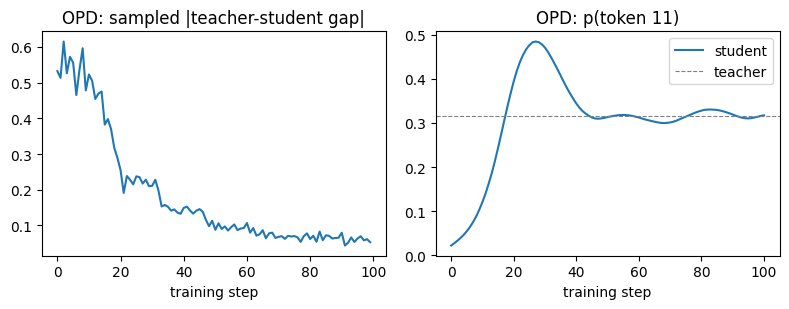

In [21]:
# 曲线: 重建 student / teacher 从头训 100 步
torch.manual_seed(2)
student = Actor().to(DEVICE); teacher = copy.deepcopy(student).eval()
with torch.no_grad():
    teacher.lm_head.bias[11] += 3.0              # teacher 只在 token 11 上和 student 不同
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
prompt = torch.tensor([[4, 5, 6]], device=DEVICE).repeat(16, 1)
p11 = lambda mdl: mdl(prompt)[:, -1].softmax(-1)[:, 11].mean().item()
with torch.no_grad():
    p11_teacher = p11(teacher)
    opd_curve, p11_curve = [], [p11(student)]
for _ in range(100):
    _, gap = opd_step(prompt, n_new=6)
    opd_curve.append(gap)
    with torch.no_grad():
        p11_curve.append(p11(student))

first_g, last_g = sum(opd_curve[:20]) / 20, sum(opd_curve[-20:]) / 20
assert last_g < first_g * 0.75, "OPD gap 没有明显下降!"
assert p11_curve[-1] > p11_curve[0], "student 没有朝 teacher 偏好的 token 移动!"
print(f'曲线      |Δ_t| {first_g:.3f} -> {last_g:.3f}')
print(f'          p(token 11)  student {p11_curve[0]:.3f} -> {p11_curve[-1]:.3f} | teacher {p11_teacher:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].plot(opd_curve); ax[0].set_title('OPD: sampled |teacher-student gap|')
ax[1].plot(p11_curve, label='student')
ax[1].axhline(p11_teacher, ls='--', c='gray', lw=0.8, label='teacher')
ax[1].set_title('OPD: p(token 11)'); ax[1].legend()
for a in ax: a.set_xlabel('training step')
plt.tight_layout(); plt.show()


### 2.5 MOPD：只补 teacher 路由

> loss 沿用 §1.4，step 沿用 §2.4 的 opd_step。新增部分只有：按 domain_ids 选择 teacher，再将 logprob 放回原 batch 的行。

router 不训练，每条回答只交给一个 teacher。


In [22]:
@torch.no_grad()
def routed_teacher_logp(ids, p_len, domain_ids=None):
    """选 teacher 并做一次 teacher-forcing (§4.4); domain_ids=None 即单 teacher 的 OPD"""
    if domain_ids is None:
        return sft_logprob(teacher, ids, p_len)                  # OPD: 只有一个 teacher
    out = torch.empty(ids.shape[0], ids.shape[1] - p_len,        # MOPD: 先开好 (B, T_resp)
                      device=ids.device, dtype=torch.float32)
    for d in domain_ids.unique().tolist():                       # 每条 prompt 只进一个 teacher
        rows = domain_ids == d
        out[rows] = sft_logprob(teachers[d], ids[rows], p_len)
    return out


**路由验收**：两个 teacher 分别偏好 token 5 / 9；每行输出须与对应 teacher 单独前向一致，换错 teacher 则不一致。

本节只验路由，不做多 teacher 的端到端训练。


In [23]:
# 梯度流向 (MOPD): 每一行必须等于对应 teacher 单独前向的结果
base = Actor().to(DEVICE)
teachers = [copy.deepcopy(base).eval(), copy.deepcopy(base).eval()]
with torch.no_grad():                            # 两个 domain teacher 各偏好一个 token
    teachers[0].lm_head.bias[5] += 2.0
    teachers[1].lm_head.bias[9] += 2.0
ids_r = torch.randint(1, V, (4, 8), device=DEVICE)
domains = torch.tensor([0, 1, 1, 0], device=DEVICE)
routed = routed_teacher_logp(ids_r, p_len=3, domain_ids=domains)
for dm in [0, 1]:
    rows = domains == dm
    assert torch.allclose(routed[rows], sft_logprob(teachers[dm], ids_r[rows], 3))
assert not torch.allclose(routed[domains == 0], sft_logprob(teachers[1], ids_r[domains == 0], 3))
print("梯度流向  MOPD routing: 每行来自对应 domain 的 teacher, 换一个就对不上  OK")


梯度流向  MOPD routing: 每行来自对应 domain 的 teacher, 换一个就对不上  OK
